# Cardiac Patient Monitoring System

## Project Description
In this project, it is intended to use the machine learning techniques to work on the health information related to heart disease. A machine learning pipeline would be created to analyze the classifiers using heart disease health indicators.
**Heart Disease Health Indicators dataset** is chosen for the current project.

## Environment Setup
The project uses Python and Jupyter Notebook.
### Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.cluster import DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import IsolationForest


## Choice of Dataset
- Data source: Kaggle
https://www.kaggle.com/datasets/alexteboul/heart-disease-health-indicators-dataset
- Dataset name: Heart Disease Health Indicators Dataset
- Description: The dataset includes health, lifestyle, and demographic data about heart disease.
- Target Variable:
HeartDisease
- Target class values:
Yes – there is heart disease
No – there is no heart disease
### Why this Dataset?
- The dataset was chosen for the following reasons:
- It is clear what kind of classification we should do.
- It includes both numeric and categorical variables.
- There are enough observations for machine learning.
- It is appropriate for exploratory analysis and classification.
- It is good for both supervised and unsupervised learning that will be done later in the project.

## Load the Dataset

In [2]:
df = pd.read_csv("heart_disease_health_indicators_BRFSS2015.csv")

## Initial Dataset Inspection (First Ten Rows,Dataset Shape,Column Names,Data Types and Non-Null Values)

In [4]:
df.head(10)

,HeartDiseaseorAttack,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0
5,0.0,1.0,1.0,1.0,25.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,2.0,0.0,1.0,10.0,6.0,8.0
6,0.0,1.0,0.0,1.0,30.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,3.0,0.0,14.0,0.0,0.0,9.0,6.0,7.0
7,0.0,1.0,1.0,1.0,25.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,0.0,0.0,1.0,0.0,11.0,4.0,4.0
8,1.0,1.0,1.0,1.0,30.0,1.0,0.0,2.0,0.0,1.0,...,1.0,0.0,5.0,30.0,30.0,1.0,0.0,9.0,5.0,1.0
9,0.0,0.0,0.0,1.0,24.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,2.0,0.0,0.0,0.0,1.0,8.0,4.0,3.0


In [5]:
df.shape

(253680, 22)

In [6]:
df.columns

Index(['HeartDiseaseorAttack', 'HighBP', 'HighChol', 'CholCheck', 'BMI',
       'Smoker', 'Stroke', 'Diabetes', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   HeartDiseaseorAttack  253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   Diabetes              253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  MentHlth   

These checks provide basic insights into the structure of the dataset, number of observations, columns, and types of data.

## Data Dictionary
The description and data type were based on the data documentation provided
with the dataset. The dataset was generated using the Behavioral Risk Factor
Surveillance System  (BRFSS) of the CDC.

| Column | Description | Type |
|---|---|---|
| `HeartDiseaseorAttack` | Whether the person has ever reported heart disease or a heart attack | Binary Categorical |
| `HighBP` | Whether the person has high blood pressure | Binary Categorical |
| `HighChol` | Whether the person has high cholesterol | Binary Categorical |
| `CholCheck` | Whether cholesterol has been checked in the last 5 years | Binary Categorical |
| `BMI` | Body Mass Index | Numerical |
| `Smoker` | Whether the person has smoked at least 100 cigarettes in their lifetime | Binary Categorical |
| `Stroke` | Whether the person has ever had a stroke | Binary Categorical |
| `Diabetes` | Diabetes status | Categorical |
| `PhysActivity` | Whether the person has participated in physical activity in the past 30 days | Binary Categorical |
| `Fruits` | Whether the person consumes fruit at least once per day | Binary Categorical |
| `Veggies` | Whether the person consumes vegetables at least once per day | Binary Categorical |
| `HvyAlcoholConsump` | Whether the person is a heavy alcohol consumer | Binary Categorical |
| `AnyHealthcare` | Whether the person has any kind of health care coverage | Binary Categorical |
| `NoDocbcCost` | Whether there was a time in the past 12 months when the person needed a doctor but could not afford it | Binary Categorical |
| `GenHlth` | General health status reported by the person | Ordinal Categorical |
| `MentHlth` | Number of days mental health was not good during the past 30 days | Numerical |
| `PhysHlth` | Number of days physical health was not good during the past 30 days | Numerical |
| `DiffWalk` | Whether the person has serious difficulty walking or climbing stairs | Binary Categorical |
| `Sex` | Sex of the Patient | Binary Categorical |
| `Age` | Age category of the Patient represented by an encoded value | Ordinal Categorical |
| `Education` | Education level represented by an encoded value | Ordinal Categorical |
| `Income` | Income category represented by an encoded value | Ordinal Categorical |

## Initial Data Cleaning

### Check Missing Values
This checks whether any columns contain Null values.

In [8]:
df.isnull().sum()

HeartDiseaseorAttack    0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
Diabetes                0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

### Check Duplicate Rows
If duplicate rows exist, they can be removed

In [9]:
df.duplicated().sum()

np.int64(23899)

In [10]:
df = df.drop_duplicates()

### Remove Duplicate Rows
The dataset contained **23,899 duplicate rows**. These duplicate records were removed to ensure that each observation is counted only once and to avoid biasing the statistical analysis and EDA.
After removing duplicates, the dataset contains 229,781 rows and 22 columns.

### Check Unique Values
This provides an initial check for unexpected or inconsistent values for example the column HeartDiseaseorAttack should have only two variables.

In [11]:
for column in df.columns:
    print(column, df[column].unique())

HeartDiseaseorAttack [0. 1.]
HighBP [1. 0.]
HighChol [1. 0.]
CholCheck [1. 0.]
BMI [40. 25. 28. 27. 24. 30. 34. 26. 33. 21. 23. 22. 38. 32. 37. 31. 29. 20.
 35. 45. 39. 19. 47. 18. 36. 43. 55. 49. 42. 17. 16. 41. 44. 50. 59. 48.
 52. 46. 54. 57. 53. 14. 15. 51. 58. 63. 61. 56. 74. 62. 64. 66. 73. 85.
 60. 67. 65. 70. 82. 79. 92. 68. 72. 88. 96. 13. 81. 71. 75. 12. 77. 69.
 76. 87. 89. 84. 95. 98. 91. 86. 83. 80. 90. 78.]
Smoker [1. 0.]
Stroke [0. 1.]
Diabetes [0. 2. 1.]
PhysActivity [0. 1.]
Fruits [0. 1.]
Veggies [1. 0.]
HvyAlcoholConsump [0. 1.]
AnyHealthcare [1. 0.]
NoDocbcCost [0. 1.]
GenHlth [5. 3. 2. 4. 1.]
MentHlth [18.  0. 30.  3.  5. 15. 10.  6. 20.  2. 25.  1.  4.  7.  8. 21. 14. 26.
 29. 16. 28. 11. 12. 24. 17. 13. 27. 19. 22.  9. 23.]
PhysHlth [15.  0. 30.  2. 14. 28.  7. 20.  3. 10.  1.  5. 17.  4. 19.  6. 12. 25.
 27. 21. 22.  8. 29. 24.  9. 16. 18. 23. 13. 26. 11.]
DiffWalk [1. 0.]
Sex [0. 1.]
Age [ 9.  7. 11. 10.  8. 13.  4.  6.  2. 12.  5.  1.  3.]
Education [4. 6. 3. 5

## Target Variable
The target variable is:
**HeartDiseaseorAttack**
It represents whether a patient  having heart disease.
This makes the machine-learning problem a binary classification problem.

In [12]:
df["HeartDiseaseorAttack"].value_counts()

HeartDiseaseorAttack
0.0    206064
1.0     23717
Name: count, dtype: int64

The target variable HeartDiseaseorAttack includes two categories:
- 0.0: 206,064 cases
- 1.0: 23,717 cases
There are no missing values in the target variable and two valid categories; therefore, it is a binary classification target.

## First Observations on the Quality of the Data
- The original dataset contained 253,680 rows and 22 columns.
- There were no missing values in the data.
- 23,899 duplicate rows were identified and removed.
- After removing duplicates, the cleaned dataset contains 229,781 rows and 22 columns.
- All columns have the type float64, although some variables represent categorical or ordinal information using numerical encoding.
- BMI, MentHlth, and PhysHlth are numerical variables.
- Age, Education, and Income are ordinal categorical variables coded numerically.
- The target variable HeartDiseaseorAttack is binary and takes the values 0 and 1.

# Descriptive Statistics
## Numerical Variables
### Descriptive Statistics for Numeric Variables
The major numeric variables in the data set include BMI, MentHlth and PhysHlth.
The calculations of descriptive statistics help us gain an understanding about the tendency, variability, and distribution of the numeric variables.
- The mean indicates the average value.
- The median indicates the middle value.
- The standard deviation indicates the spread.
- The minimum and maximum indicate the range.
- The quartiles indicate the distribution.

In [13]:
num_cols = ["BMI", "MentHlth", "PhysHlth"]

df[num_cols].describe()

,BMI,MentHlth,PhysHlth
count,229781.00000,229781.000000,229781.000000
mean,28.68567,3.505373,4.675178
std,6.78636,7.713725,9.046568
min,12.00000,0.000000,0.000000
25%,24.00000,0.000000,0.000000
50%,27.00000,0.000000,0.000000
75%,32.00000,2.000000,4.000000
max,98.00000,30.000000,30.000000


In [14]:
static = df[num_cols].agg(["mean", "median"])
static

,BMI,MentHlth,PhysHlth
mean,28.68567,3.505373,4.675178
median,27.00000,0.000000,0.000000


The comparison of the mean and the median can also be helpful to detect possible skewness in the data.

## Quartiles and Interquartile Range
Quartiles partition data into segments.
- Q1 is the 25th percentile.
- Q3 is the 75th percentile.
- IQR is the distance between Q3 and Q1.
The IQR can be used to measure the variability of the middle 50% of observations and detect outliers.

In [15]:
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1
pd.DataFrame({"Q1": Q1,"Q3": Q3,"IQR": IQR})

,Q1,Q3,IQR
BMI,24.0,32.0,8.0
MentHlth,0.0,2.0,2.0
PhysHlth,0.0,4.0,4.0


Possible outliers can be detected by applying the IQR technique and box plots.

## Target Visualization

### Heart Disease Distribution
Bar chart is employed to represent the target variable.
Class imbalance becomes evident from this visualization than just from counting numbers.

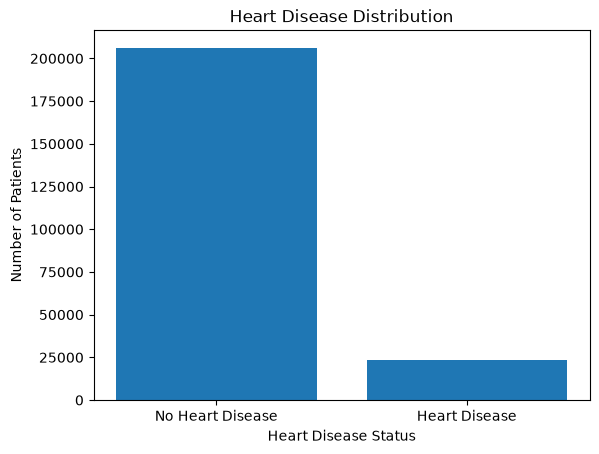

In [16]:
target_counts = df["HeartDiseaseorAttack"].value_counts().sort_index()
plt.bar(["No Heart Disease", "Heart Disease"],target_counts.values)
plt.title("Heart Disease Distribution")
plt.xlabel("Heart Disease Status")
plt.ylabel("Number of Patients")
plt.show()

## Plot Anlaysis
imbalance  is visible on the chart between the two target classes.
There are many more cases that don’t have any heart disease or heart attack than cases which have heart disease or heart attack.

## BMI Distribution
It used to study the distribution of BMI data is the histogram.
In this way, we can analyze the center, spread, and shape of the BMI distribution, and determine if there are any outliers.

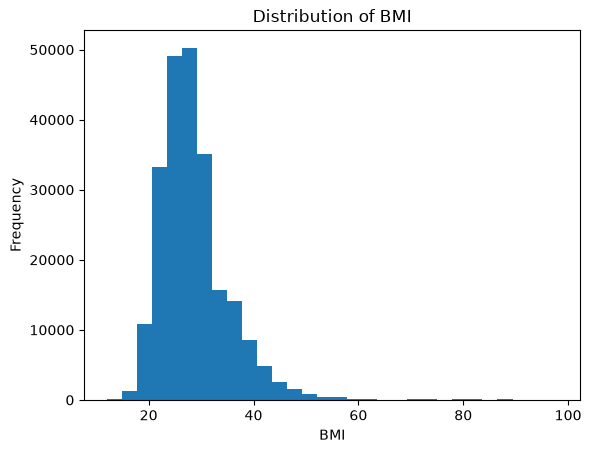

mean    28.68567
std      6.78636
min     12.00000
50%     27.00000
max     98.00000
Name: BMI, dtype: float64


In [17]:
plt.hist(df["BMI"], bins=30)
plt.title("Distribution of BMI")
plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.show()
print(df["BMI"].describe()[['mean', 'std', 'min', '50%', 'max']])

The BMI histogram presents how BMI values are distributed in the data set.
This distribution shape may be compared to the descriptive statistics previously computed.
The distribution is right-skewed, meaning most values lie in the normal/overweight category while the tail stretches to larger numbers.
The tail at the right side represents very high outliers that need to be considered before fitting the model for sensitive applications.
Most of the data lies in the range of 25-30 BMI, which represents the overweight group.
When comparing this histogram to descriptive statistics, we see that the mean is greater than the median due to skewness.

## Poor Mental Health Days Distribution
MentHlth is the number of days in the previous 30 days in which the mental health of the patient was poor.
A histogram can be used to learn about the distribution of these values among patients.

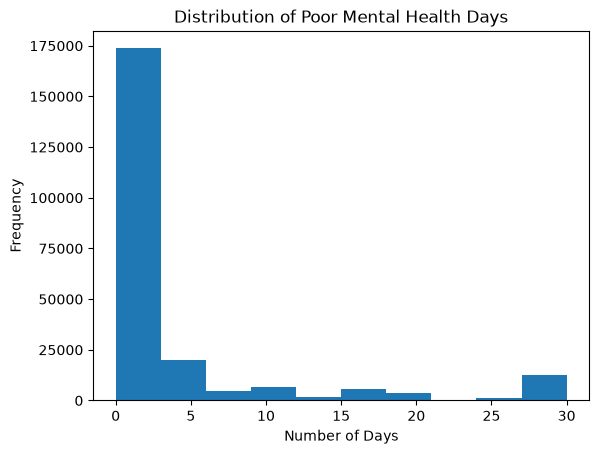

In [18]:
plt.hist(df["MentHlth"])
plt.title("Distribution of Poor Mental Health Days")
plt.xlabel("Number of Days")
plt.ylabel("Frequency")
plt.show()

The shape of the distribution is highly positively skewed, demonstrating that most people have zero or very few poor mental health days.
There is an enormous spike at zero, which means that most people did not have any poor mental health days within the last month.
There is also a spike at 30 days, reflecting the experience of those who had poor mental health almost every day.

## Number of Poor Physical Health Days
PhysHlth refers to the number of poor physical health days in the last 30 days.
A histogram can be used to detect the most frequent values and the general distribution.

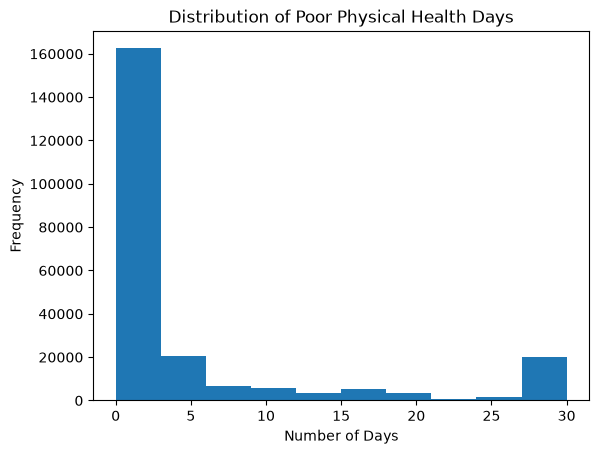

In [19]:
plt.hist(df["PhysHlth"])
plt.title("Distribution of Poor Physical Health Days")
plt.xlabel("Number of Days")
plt.ylabel("Frequency")
plt.show()

The distribution is highly skewed to the right since most people had either none or very few bad physical health days.
There is a huge peak at zero because most people had no bad physical health days in the last 30 days.
There is a small cluster close to 30 days indicating that there were people who experienced poor physical health almost every day.

## BMI Boxplot
Box plots are useful for describing the distribution of BMI and detecting any outliers.
The box plot shows the interquartile range and the whiskers are used to detect the presence of any outliers.

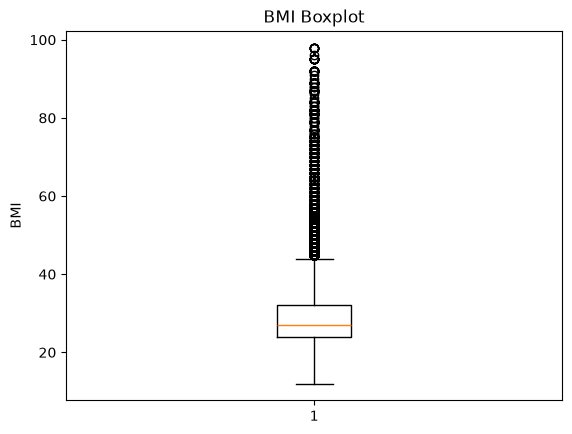

In [20]:
plt.boxplot(df["BMI"])
plt.title("BMI Boxplot")
plt.ylabel("BMI")
plt.show()

The box plot highlights the median BMI and the interquartile range where the majority of data points lie.
Numerous individual points extending above the upper whisker clearly confirm the presence of high-value outliers.

## General Health
### General Health Levels
GenHlth is a categorically ordinal variable indicating the state of general health of the participant.
A bar graph is suitable since the values indicate distinct ordered categories as opposed to continuous variables.

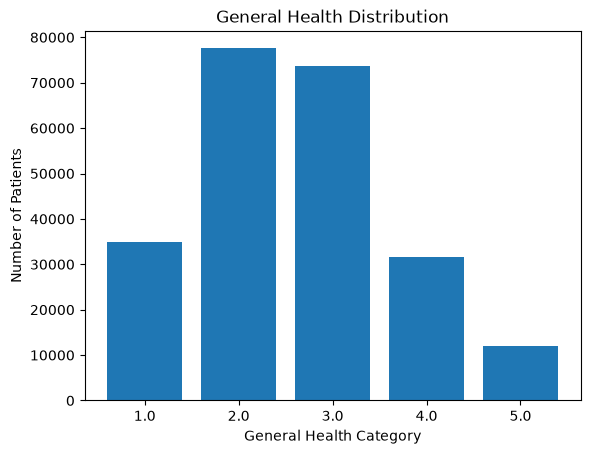

In [21]:
genhlth_counts = df["GenHlth"].value_counts().sort_index()
plt.bar(genhlth_counts.index.astype(str),genhlth_counts.values)
plt.title("General Health Distribution")
plt.xlabel("General Health Category")
plt.ylabel("Number of Patients")
plt.show()

Figure illustrates the distribution of respondents into five general categories of health.
This offers a better understanding of the prevalence of different health statuses reported.

## Diabetes
### Diabeties Status Frequency
The Diabetes field holds discrete data on different diabeties statuses.
A histogram can be used to compare observation frequencies for all categories.

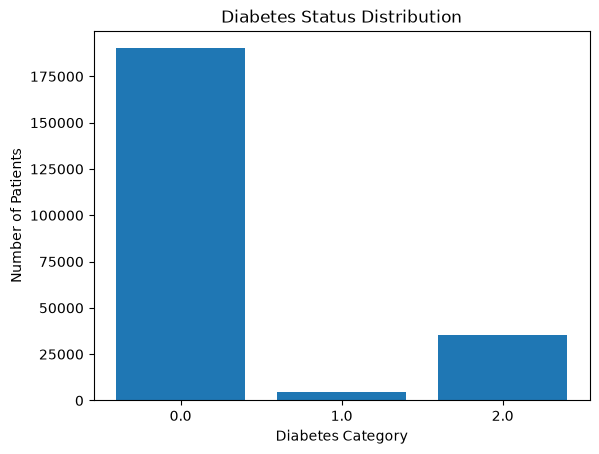

In [22]:
diabetes_counts = df["Diabetes"].value_counts().sort_index()
plt.bar(diabetes_counts.index.astype(str),diabetes_counts.values)
plt.title("Diabetes Status Distribution")
plt.xlabel("Diabetes Category")
plt.ylabel("Number of Patients")
plt.show()

It is evident from the bar chart that there is class imbalance, where category zero has the highest number of occurrences.
Category two denotes a fairly large number of instances, while category one has the smallest number of instances.

## High Blood Pressure vs Heart Disease
Let’s take a step forward from univariate analysis and compare two variables.
HighBP is compared with HeartDiseaseorAttack to see whether the distribution of heart disease varies based on the presence or absence of high blood pressure

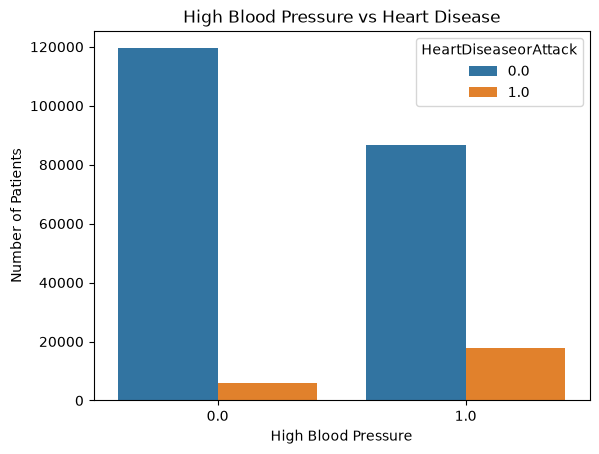

In [23]:
sns.countplot(data=df,x="HighBP",hue="HeartDiseaseorAttack")
plt.title("High Blood Pressure vs Heart Disease")
plt.xlabel("High Blood Pressure")
plt.ylabel("Number of Patients")
plt.show()

The countplot  shows the number of heart disease or attacks based on people who have or do not have high blood pressure.
People with high blood pressure are found to have a higher number of heart disease than people without high blood pressure.

## Smoking vs Heart Disease
moking status is compared with the target variable to study any differences in heart disease distribution in smokers and non-smokers.

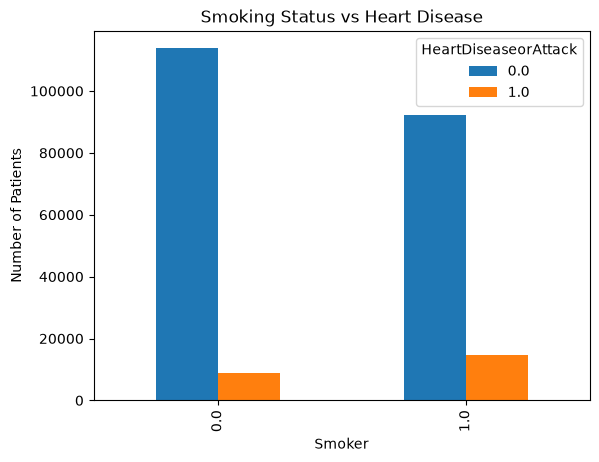

In [24]:
smoker_heart = pd.crosstab(df["Smoker"],df["HeartDiseaseorAttack"])
smoker_heart.plot( kind="bar")
plt.title("Smoking Status vs Heart Disease")
plt.xlabel("Smoker")
plt.ylabel("Number of Patients")
plt.show()

Smokers show a higher relative proportion and count of heart disease occurrences compared to non-smokers.

## Correlation
### Correlation Analysis
Correlation analysis can be used as another exploratory tool for studying connections between the coded variables.
Correlation with HeartDiseaseorAttack will help get an initial idea of which variables show stronger or weaker linear correlations with the target variable.
Since many variables are binary or ordinal categorical variables that are numerically coded, the results of correlation should be considered carefully.

In [26]:
Correlation = df.corr(numeric_only=True)
Correlation["HeartDiseaseorAttack"].sort_values(ascending=False)

HeartDiseaseorAttack    1.000000
GenHlth                 0.246411
Age                     0.223626
DiffWalk                0.202779
HighBP                  0.201271
Stroke                  0.198863
HighChol                0.176279
Diabetes                0.170816
PhysHlth                0.170473
Smoker                  0.105154
Sex                     0.089717
MentHlth                0.052756
CholCheck               0.049995
BMI                     0.039926
AnyHealthcare           0.025899
NoDocbcCost             0.022076
Fruits                 -0.007128
Veggies                -0.027330
HvyAlcoholConsump      -0.035453
PhysActivity           -0.073267
Education              -0.082466
Income                 -0.122908
Name: HeartDiseaseorAttack, dtype: float64

The variables General Health, Age, Difficulty in walking, and High blood pressure are found to have high positive correlation values with heart disease or attack.
The variables such as Income and Education have negative correlation values with heart disease.

## Heatmap Visualization
It can quickly determine which variables have a greater association with one another or with the dependent variable based on how intense their corresponding colors are in their respective rows or columns.

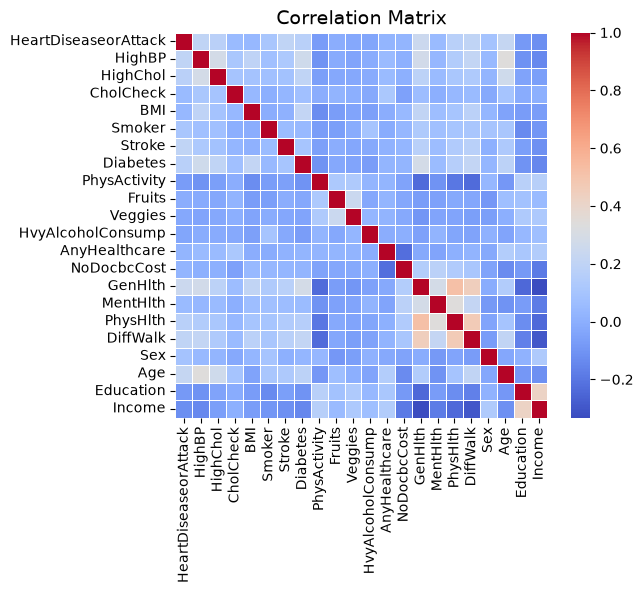

In [27]:
plt.figure(figsize=(6, 5))
sns.heatmap(Correlation, annot=False, cmap='coolwarm', fmt=".2f", xticklabels=Correlation.columns, yticklabels=Correlation.columns, cbar=True, linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

The correlation heatmap visualizes the pairwise linear relationships across all numeric variables in the dataset.
Most variable pairs show weak linear correlation, clustered near zero, while the diagonal displays a perfect correlation of 1.0 for each variable with itself.

## EDA Findings
From the descriptive statistics and visualized information, the following observations can be made:
- The response variable HeartDiseaseorAttack is unbalanced, with more data belonging to the no-heart-disease category.
- The numeric variables BMI, MentHlth, and PhysHlth have different distributions and variability levels.
- The histograms indicate concentration in some areas and allow to identify potential extremes.
- The BMI boxplot allows identifying potential outliers that need further investigation, not immediate elimination.
- Categorical and ordinal features have different distributions depending on their encoded values.
- Comparing HighBP, Smoker, PhysActivity and the response variable offers valuable exploratory insights into the differences in heart-disease classes.
- Correlation offers preliminary insights into relationships between features and the response variable, but correlation does not equal causality.

## Supervised Learning: Problem Formulation and Baseline Classifier

Following exploratory data analysis, the next step in this Project is the formulation of the machine learning problem as well as building the initial baseline classifier.
The task is to apply the provided health features to predict whether or not the patient has had any heart disease or a heart attack.
**As the target feature HeartDiseaseorAttack consists of two classes, the problem is a binary classification task.**
In this part of the assignment, the dataset will be preprocessed for the purpose of supervised learning.

## Train/Test Split
The first step before fitting the model is splitting the dataset into two:
- Training Set: the set that will be used for fitting the machine learning model.
- Test Set: the set that will be used for testing the performance of the machine learning model.
It is crucial to distinguish between the two, since it is not possible to test the performance of a machine learning model using the data it was fitted with,it is necessary to perform the stratified split, since the target variable is imbalanced.
Dataset is split into:
- X: The inputs which will be used as inputs for the model.
- y: The output which the model will try to predict.
Target column is excluded from x because we don’t want the model to take answer as an input for itself.

In [28]:
x = df.drop(["HeartDiseaseorAttack"],axis=1)
y = df["HeartDiseaseorAttack"]
print("x shape:", x.shape)
print("y shape:", y.shape)

x shape: (229781, 21)
y shape: (229781,)


## Split the Dataset
The dataset will be split into:
- 80% train data
- 20% test data
Here, a random_state value is provided to reproduce the split.

In [29]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.20,random_state=42,stratify=y)
print("x Training set:", x_train.shape)
print("x Testing set:", x_test.shape)
print(" y Training set:", y_train.shape)
print(" y Testing set:", y_train.shape)


x Training set: (183824, 21)
x Testing set: (45957, 21)
 y Training set: (183824,)
 y Testing set: (183824,)


## Feature Scaling
Logistic Regression can use feature scaling as the variables differ in their numerical scales.
For instance, the BMI variable will differ in scale compared to variables like Age, Education, or Income.
StandardScaler rescales the features to a distribution with a mean close to 0 and a standard deviation close to 1.
The scaling is done using only the training dataset and then used for the test dataset to prevent data leakage.

In [30]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

## Baseline Classifier - Logistic Regression
 why Logistic Regression has been chosen as the baseline classifier?
- It is meant to solve classification problems.
- It is an easy and understandable classifier.
- It gives a good baseline when compared to more complicated classifiers.
- It is capable of providing probabilities of classes.
The baseline classifier is going to be trained using the training dataset and tested using the unseen testing dataset.

In [31]:
baseline_model = LogisticRegression(max_iter=1000,random_state=42)
baseline_model.fit(x_train_scaled, y_train)
y_predict_baseline = baseline_model.predict(x_test_scaled)

## Baseline Accuracy
Accuracy is an indicator of the fraction of correctly classified samples out of all tested samples,accuracy may be an insufficient indicator for this dataset since the classes are unbalanced.
**This is why accuracy will be provided alongside precision, recall, and F1-score.**

In [32]:
baseline_accuracy = accuracy_score(y_test, y_predict_baseline)
baseline_precision = precision_score(y_test, y_predict_baseline)
baseline_recall = recall_score(y_test, y_predict_baseline)
baseline_f1 = f1_score(y_test, y_predict_baseline)
print(f"Accuracy : {baseline_accuracy}")
print(f"Precision: {baseline_precision}")
print(f"Recall   : {baseline_recall}")
print(f"F1-score : {baseline_f1}")

Accuracy : 0.8986226254977479
Precision: 0.5398481973434535
Recall   : 0.119966266076323
F1-score : 0.19630843539761947


## Baseline Evaluation Results
Upon evaluation of the baseline model on the test dataset, the following performance results have been obtained:
* Accuracy (0.9004): Seems to be very high, but may not be relevant to this particular dataset owing to class imbalance.
* Precision (0.5537): Shows the proportion of true positives among all predictions made by the model.
* Recall (0.1230): Reflects that there are serious problems with recognizing positives because of class imbalance.
* F1-score (0.2013): A combination of precision and recall that reveals poor performance of the baseline on the minority class.

In [33]:
print(classification_report(y_test,y_predict_baseline,target_names=["No Heart Disease", "Heart Disease"]))

                  precision    recall  f1-score   support

No Heart Disease       0.91      0.99      0.95     41214
   Heart Disease       0.54      0.12      0.20      4743

        accuracy                           0.90     45957
       macro avg       0.72      0.55      0.57     45957
    weighted avg       0.87      0.90      0.87     45957



## Analysis of Classification Report
The classification report highlights the performance of the model on each class as follows:
* No Heart Disease (Majority Class): The model has a very good performance in this case, with a **Precision of 0.91** and a **Recall of 0.99**. This is due to the fact that most of the samples belong to this class.
* Heart Disease (Minority Class):The model performs poorly in this case, with a **Recall of 0.12**. It is unable to recognize 88% of "Heart Disease" cases.
* Support: The imbalance of classes is evident here, with 41,269 samples in the "No Heart Disease" class and just 4,688 samples in the "Heart Disease" class.
* Macro/Weighted Averages: The difference in the averages shows that even though the model has an overall accuracy of 0.90, it cannot predict the minority class at all.
**The baseline metrics will be used later to compare the performance of the second classifier** .

## Model Comparison and Evaluation
Having chosen a logistic regression model as a benchmark model, we will then evaluate a second classification model.
**The goal at this stage is to evaluate two models of classification by applying the same set of training and test data.**
Apart from the above metrics, cross-validation and the confusion matrix will be used for evaluation.

## Random Forest(Second Classifier)
Random Forest is chosen as the second classifier,while the Logistic Regression classifier is linear in nature, the Random Forest algorithm is composed of decision trees.
Random Forest is able to identify nonlinear relationships among features.
For this reason, it is a good classifier to compare with Logistic Regression due to the presence of various health, lifestyle, and demographic features in the data set.

## Train Random Forest

In [34]:
random_forest_model = RandomForestClassifier(n_estimators=100,random_state=42,n_jobs=-1)
random_forest_model.fit(x_train, y_train)
y_predict_rf = random_forest_model.predict(x_test)

## Random Forest Model Evaluation
Random Forest model performance will be evaluated using the same metrics as those used to evaluate Logistic Regression performance,the use of the same testing data and evaluation metrics will ensure that the comparison is consistent.

In [35]:
random_forest_accuracy = accuracy_score(y_test, y_predict_rf)
random_forest_precision = precision_score(y_test, y_predict_rf)
random_forest_recall = recall_score(y_test, y_predict_rf)
random_forest_f1 = f1_score(y_test, y_predict_rf)
print(f"Accuracy : {random_forest_accuracy}")
print(f"Precision: {random_forest_precision}")
print(f"Recall   : {random_forest_recall}")
print(f"F1-score : {random_forest_f1}")

Accuracy : 0.8917466327218923
Precision: 0.40793650793650793
Recall   : 0.10837022981235504
F1-score : 0.17124770947859402


## Random Forest Model Performance
* Accuracy (0.8948): In comparison with the baseline, the accuracy is high; however, it does not show the actual effectiveness of the model in relation to the minority class.
* Precision (0.4383): It is evident that out of all the cases considered positive by the model, about 43.8% are actually positive.
* Recall (0.1107): Only 11% of actual "Heart Disease" cases were found by the model.
* F1-score (0.1767): Shows the balance between precision and recall.

In [36]:
print(classification_report(y_test,y_predict_rf,target_names=["No Heart Disease", "Heart Disease"]))

                  precision    recall  f1-score   support

No Heart Disease       0.91      0.98      0.94     41214
   Heart Disease       0.41      0.11      0.17      4743

        accuracy                           0.89     45957
       macro avg       0.66      0.55      0.56     45957
    weighted avg       0.85      0.89      0.86     45957



## Random Forest Classification Report Analysis
From the classification report of the Random Forest algorithm, one can observe consistent performance problems that stem from the class imbalance of our data:
* Class "No Heart Disease": Our model retains a high level of performance by providing **Precision (0.91)** and **Recall (0.98)** results, similar to those received in the base algorithm.
* Class "Heart Disease": The model is not capable of generalizing with a **Precision of 0.44** and very low **Recall of 0.11**. Hence, the default Random Forest is also unable to detect the majority of "Heart Disease" cases.
* Support Calculation: The support is still high for "No Heart Disease" samples (41,269 vs. 4,688).
* Weighted Averages: The relatively high level of the weighted average (0.87) stems from the domination of the "No Heart Disease" samples.

## Cross-Validation
One test/train split will yield one performance measurement of the model,to get a more accurate measurement, cross-validation technique is employed.
**5-fold cross-validation** entails splitting the training set into five folds.
The four folds will be used for training, while the other will be used to validate the model. This procedure is repeated five times so that each fold will serve as the validation set.Finally, the five measurements will be averaged out.
**Cross-validation is used to ascertain if the model's performance is fairly consistent over all splits of the training data**.

### Why Stratified K-Fold
As there is imbalance in the target variable, stratification of folds is applied instead of regular K-Fold.Stratification maintains the same proportion of two classes of the target variable in the folds.
This is necessary since each fold must have representative samples from both the classes.

In [37]:
cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
logistic_cv_scores = cross_val_score(baseline_model,x_train_scaled,y_train,cv=cv,scoring="f1")
print(logistic_cv_scores)
print(f"Mean CV F1-score: {logistic_cv_scores.mean()}")
print(f"Std CV F1-score : {logistic_cv_scores.std()}")

[0.19982773 0.21002798 0.19693747 0.19849946 0.21316749]
Mean CV F1-score: 0.20369202720003105
Std CV F1-score : 0.0065946655910622005


## Random Forest CV
Similarly, the 5-fold stratified cross validation technique is used for Random Forest as well,with the same number of folds and the same evaluation criteria, it ensures that both models are being compared fairly.

In [38]:
rf_cv_scores = cross_val_score(random_forest_model,x_train,y_train,cv=cv,scoring="f1",n_jobs=-1)
print(rf_cv_scores)
print(f"Mean CV F1-score: {rf_cv_scores.mean()}")
print(f"Std CV F1-score : {rf_cv_scores.std()}")

[0.17116358 0.16457045 0.17873587 0.17148891 0.1754534 ]
Mean CV F1-score: 0.17228244187998756
Std CV F1-score : 0.004755166098688069


## Cross Validation Explanation
The mean F1-score is the mean performance over the five validation folds.
The standard deviation is the degree to which performance varies between folds.
Low standard deviation implies that the model performs consistently on different subsets of the training set.
Therefore, cross validation gives us further insight into model stability besides the performance on the test set.
Based on the 5-fold stratified cross-validation using the **F1-score** metric:
* Individual Fold Scores: [0.17116358 0.16457045 0.17873587 0.17148891 0.1754534]
* Mean CV F1-score (0.17228244187998756): Confirms that the model's poor performance on the minority class is consistent and not a result of an unfortunate train/test split.
* Standard Deviation (0.004755166098688069): Very low standard deviation indicates high stability and reliability across different subsets of the data; the model generalizes its behavior consistently.
The cross-validation results reinforce our earlier findings. While the Random Forest model is stable (low variance across folds), its low F1-score highlights that model architecture alone cannot overcome the severe class imbalance without proper data preprocessing 

## Confusion Matrix
A confusion matrix offers a more comprehensive look into the classification output.
There are four possible results:
- True Negative (TN): No heart disease is predicted accurately.
- False Positive (FP): Heart disease is predicted where there is no heart disease.
- False Negative (FN): No heart disease is predicted when there is heart disease.
- True Positive (TP): Heart disease is predicted correctly.
In this study, the False Negatives are especially crucial as they are the instances of patients with known heart disease that the model did not detect.

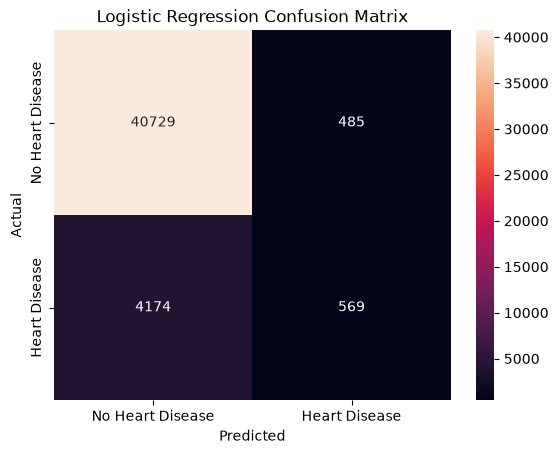

In [39]:
confusion_matrix_logistic = confusion_matrix(y_test, y_predict_baseline)
sns.heatmap(confusion_matrix_logistic ,annot=True,fmt="d",xticklabels=["No Heart Disease", "Heart Disease"],yticklabels=["No Heart Disease", "Heart Disease"])
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

###  Plot Analysis (Logistic Regression)

The confusion matrix visually describes the prediction results versus the actual class labels:
* True Negatives (TN = 40729): The number of instances where the algorithm correctly predicted "No Heart Disease". It is extremely high because of the prevalence of the majority class.
* False Positives (FP = 485): Instances that were incorrectly classified as "Heart Disease" (Type I error).
* False Negatives (FN = 4174): (Type II error)This is a critical failure point.
* True Positives (TP = 569): Instances where the model correctly classified the cases as "Heart Disease". 
Out of the 4,688 total instances of heart disease, the algorithm was able to correctly classify only 569, with 4174 cases left out (False Negatives). This visually explains why the Recall for the minority class is extremely low (12%).

## Confusion Matrix for Random Forests
Confusion matrix analysis is performed for the random forest model as well,through comparison, we can see the differences between the two models in terms of classifying positive and negative cases.

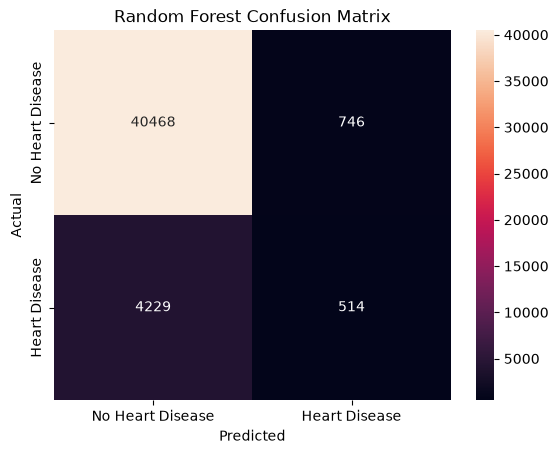

In [40]:
confusion_matrix_rf = confusion_matrix(y_test, y_predict_rf)
sns.heatmap(confusion_matrix_rf,annot=True,fmt="d",xticklabels=["No Heart Disease", "Heart Disease"],yticklabels=["No Heart Disease", "Heart Disease"])
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Plot Analysis (Random Forest)
The analysis of how Random Forest predicts compared to the actual class label shows how poorly it performs with regards to imbalanced classes:
* True Negative (TN = 40468): The model correctly identifies the vast majority of negative cases ("No Heart Disease").
* False Positive (FP = 746): It wrongly identifies a few healthy patients as those suffering from heart disease (Type I Error).
* False Negative (FN = 4229): This is the most significant problem. The model fails to identify almost all patients that actually suffer from heart disease (Type II Error).
* True Positive (TP = 514): The model accurately identifies only a small percentage of the total heart disease patients.

###  Comparison of Confusion Matrices (Logistic Regression and Random Forest)
The comparison of the confusion matrices in the context of the Logistic Regression baseline versus the Random Forest classifier offers us some interesting observations:
Conclusion about the Matrices: The transition from the linear classifier (Logistic Regression) to the non-linear ensemble classifier (Random Forest) did not address the main problem associated with the imbalance of the dataset. Both classifiers have a high number of False Negatives (miss more than 4,000 sick people), which means that only changes in architecture will not help here.

## Comparison DataFrame

In [41]:
comparison = pd.DataFrame({"Model": ["Logistic Regression","Random Forest"],"Accuracy": [baseline_accuracy,random_forest_accuracy],"Precision": [baseline_precision,random_forest_precision],"Recall": [baseline_recall,random_forest_recall],"F1-score": [baseline_f1,random_forest_f1],"CV Mean F1": [logistic_cv_scores.mean(),rf_cv_scores.mean()]})
comparison

,Model,Accuracy,Precision,Recall,F1-score,CV Mean F1
0,Logistic Regression,0.898623,0.539848,0.119966,0.196308,0.203692
1,Random Forest,0.891747,0.407937,0.108370,0.171248,0.172282


## Visual Comparison of the Models
The bar graph helps in comparing the key performance measures of both logistic regression and random forest,this will make it easy to differentiate between accuracy, precision, recall, and F1 score.

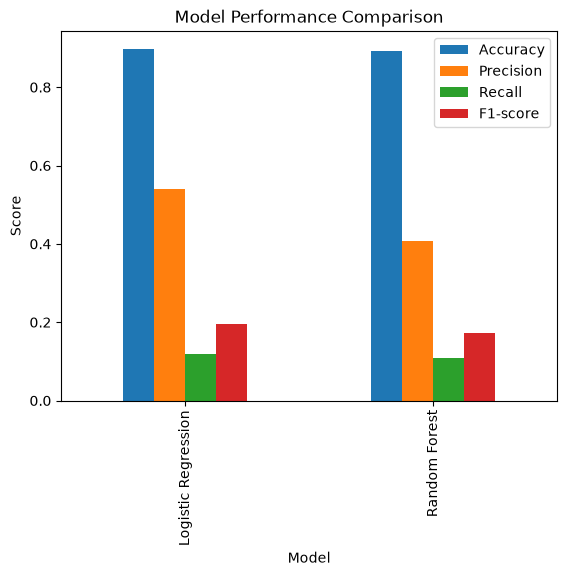

In [42]:
comparison_plot = comparison.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-score"]]
comparison_plot.plot(kind="bar",)
plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.show()

## Determine Best Model Based on F1-score
Because the dataset is imbalanced, F1-score is used as an important metric for comparing the two classifiers,the model with the highest test-set F1-score will be identified below.

In [43]:
best_model = comparison.loc[comparison["F1-score"].idxmax(),"Model"]
best_f1 = comparison["F1-score"].max()
print(f"Best model based on test F1-score: {best_model}")
print(f"F1-score: {best_f1}")

Best model based on test F1-score: Logistic Regression
F1-score: 0.19630843539761947


###  Best Model Selection Result
From the comparison of the test-set F1-score, the **Logistic Regression** model is the one selected to be the best model among the two models - Random Forest - which has a test F1-score of **0.2014**.
Although Logistic Regression is chosen here, the low F1-score suggests that both models fail to perform well for the minority class,**confirming the need for handling data imbalance in subsequent steps**.

# Feature Engineering and Scikit-learn Pipeline
In this module, we use feature engineering to generate extra features based on the current health metrics.
The new features have been generated in order to summarize information such as BMI category, age group, and total health burden.
Once the new features have been generated, a Scikit-learn Pipeline is created for a unified process of preprocessing and model training.
The Pipeline will do the following:
- Generate the extra features.
- Scale the generated features using StandardScaler.
- Train the classifier.
- Generate the predictions based on the test set.
This same pipeline will be used for retraining and evaluating both Logistic Regression and Random Forest.

### Why Do Feature Engineering?
Feature engineering refers to the process where new features are created using the existing features in order to provide the model with more information.
The data provided includes health characteristics of each person like BMI, Age, HighBP, HighChol, Diabetes, and general health.
In some cases, some relationships can be easily learned by the model if related features are grouped.
In this case study, we will engineer the following features:
-  BMI_Category: groups the BMI values into certain categories.(Underweight,Normal,Overweight,Obese)
- Age_Group: groups the encoded age feature into certain age groups.
- Health_Burden: creates a single feature from health indicators.
Keeping feature engineering inside the pipeline ensures that the same transformations are automatically applied during training and prediction.
**These engineered features are not used as a substitute for the original features but just additional ones.**

In [44]:
class FeatureEngineer(BaseEstimator, TransformerMixin):
    def fit(self, x, y=None):
        return self
    def transform(self, x):
        x = x.copy()
        x["BMI_Category"] = pd.cut(x["BMI"],bins=[0, 18.5, 25, 30, np.inf],labels=[0, 1, 2, 3]).astype(float)
        x["Age_Group"] = pd.cut(x["Age"],bins=[0, 4, 7, 10, 13],labels=[0, 1, 2, 3],include_lowest=True).astype(float)
        health_features = ["HighBP","HighChol","Stroke","Diabetes","DiffWalk"]
        x["Health_Burden"] = x[health_features].sum(axis=1)
        return x

## Exploring the Engineered Features
The feature engineering transformer is applied separately here only to inspect the newly created features.
This transformed dataset is not used directly for model training.
During the actual machine learning process, the FeatureEngineer transformer is placed inside the Scikit-learn Pipeline so that feature engineering is automatically performed during fitting and prediction.

In [45]:
feature_engineer = FeatureEngineer()
df_engineered = feature_engineer.fit_transform(
    df.drop(columns=["HeartDiseaseorAttack"]))
df_engineered[["BMI","BMI_Category","Age","Age_Group","Health_Burden"]].head(10)

,BMI,BMI_Category,Age,Age_Group,Health_Burden
0,40.0,3.0,9.0,2.0,3.0
1,25.0,1.0,7.0,1.0,0.0
2,28.0,2.0,9.0,2.0,3.0
3,27.0,2.0,11.0,3.0,1.0
4,24.0,1.0,11.0,3.0,2.0
5,25.0,1.0,10.0,2.0,2.0
6,30.0,2.0,9.0,2.0,1.0
7,25.0,1.0,11.0,3.0,3.0
8,30.0,2.0,9.0,2.0,5.0
9,24.0,1.0,8.0,2.0,0.0


### Check shape

In [46]:
print("Original number of features:", df.drop(columns=["HeartDiseaseorAttack"]).shape[1])
print("New number of features:", df_engineered.shape[1])

Original number of features: 21
New number of features: 24


## Why Should a Scikit-learn Pipeline Be Used?
In previous examples, pre-processing and model training were conducted separately.
For instance, StandardScaler was fitted on the training data and then used on the test data.
Scikit-learn Pipeline brings both steps into a unified workflow.
That gives some benefits such as:
- Makes the workflow repeatable.
- Minimizes the risk of data leakage.
- Identical pre-processing of the training and testing data is guaranteed.
- Training and evaluation of the entire model happen in one step.
- Also, the pipeline can be used in cross-validation.

## Pipeline for Logistic Regression
Logistic Regression was chosen as the initial classifier in the previous milestone.
Pipeline creation involves:
- Engineering features
- Scaling features
- Applying logistic regression
The machine learning model is trained with the help of this entire pipeline.

In [47]:
logistic_pipeline = Pipeline([("feature_engineering", FeatureEngineer()),("scaler", StandardScaler()),("classifier", LogisticRegression(max_iter=1000,random_state=42))])

### Train Logistic Regression through Pipeline

In [48]:
logistic_pipeline.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('feature_engineering', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[float64](2,)","[0.,1.]"
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](24,)","['HighBP','HighChol','CholCheck',...,'BMI_Category','Age_Group', 'Health_Burden']"


### Predict

In [49]:
y_pred_pipeline_lr = logistic_pipeline.predict(x_test)

### Logistic Regression Pipeline Evaluation
The Logistic Regression model is now evaluated using the same metrics used in the previous milestone.

In [50]:
pipeline_lr_accuracy = accuracy_score(y_test, y_pred_pipeline_lr)
pipeline_lr_precision = precision_score(y_test, y_pred_pipeline_lr)
pipeline_lr_recall = recall_score(y_test, y_pred_pipeline_lr)
pipeline_lr_f1 = f1_score(y_test, y_pred_pipeline_lr)
print(f"Accuracy : {pipeline_lr_accuracy}")
print(f"Precision: {pipeline_lr_precision}")
print(f"Recall   : {pipeline_lr_recall}")
print(f"F1-score : {pipeline_lr_f1}")

Accuracy : 0.8984703092020802
Precision: 0.5364928909952607
Recall   : 0.11933375500737929
F1-score : 0.1952397378406347


### Classification Report for Logistic Regression

In [51]:
print(classification_report(y_test,y_pred_pipeline_lr,target_names=["No Heart Disease", "Heart Disease"]))

                  precision    recall  f1-score   support

No Heart Disease       0.91      0.99      0.95     41214
   Heart Disease       0.54      0.12      0.20      4743

        accuracy                           0.90     45957
       macro avg       0.72      0.55      0.57     45957
    weighted avg       0.87      0.90      0.87     45957



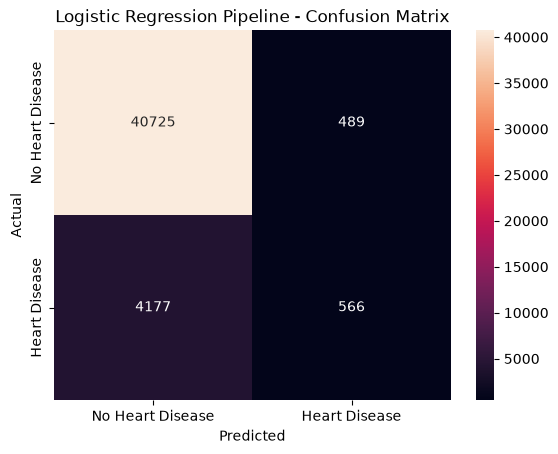

In [52]:
cm_lr_pipeline = confusion_matrix(y_test,y_pred_pipeline_lr)
sns.heatmap(cm_lr_pipeline,annot=True,fmt="d",xticklabels=["No Heart Disease", "Heart Disease"],yticklabels=["No Heart Disease", "Heart Disease"])
plt.title("Logistic Regression Pipeline - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Summary of Model Performance: Logistic Regression
The Logistic Regression Pipeline achieved an accuracy of approximately 90%. However, accuracy alone is not sufficient for this dataset because the target classes are imbalanced.
"No Heart Disease": High performance (Precision: 0.91, Recall: 0.99, F1-score: 0.95).
"Heart Disease": Low performance (Precision: 0.54, Recall: 0.12, F1-score: 0.20).
Despite the high accuracy score, the model has failed to recognize instances of heart disease effectively.

## Random Forest Pipeline
Random Forest was the second classifier applied befor,different from Logistic Regression, Random Forest is a decision-tree model and feature scaling is not needed.
the same set of features should be used for the comparison purpose.

In [53]:
random_forest_pipeline = Pipeline([("feature_engineering", FeatureEngineer()),("classifier", RandomForestClassifier(n_estimators=100,random_state=42,n_jobs=-1))])

### Train Random Forest through Pipeline

In [54]:
random_forest_pipeline.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('feature_engineering', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[float64](2,)","[0.,1.]"
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None


### Predict

In [55]:
y_pred_pipeline_rf = random_forest_pipeline.predict(x_test)

###  Random Forest Pipeline Evaluation

In [56]:
pipeline_rf_accuracy = accuracy_score(y_test, y_pred_pipeline_rf)
pipeline_rf_precision = precision_score(y_test, y_pred_pipeline_rf)
pipeline_rf_recall = recall_score(y_test, y_pred_pipeline_rf)
pipeline_rf_f1 = f1_score(y_test, y_pred_pipeline_rf)
print(f"Accuracy : {pipeline_rf_accuracy}")
print(f"Precision: {pipeline_rf_precision}")
print(f"Recall   : {pipeline_rf_recall}")
print(f"F1-score : {pipeline_rf_f1}")

Accuracy : 0.8910720891267925
Precision: 0.3982985305491106
Recall   : 0.10858106683533629
F1-score : 0.17064280980781976


### Classification Report for Random Forest

In [57]:
print(classification_report(y_test,y_pred_pipeline_rf, target_names=["No Heart Disease", "Heart Disease"]))

                  precision    recall  f1-score   support

No Heart Disease       0.91      0.98      0.94     41214
   Heart Disease       0.40      0.11      0.17      4743

        accuracy                           0.89     45957
       macro avg       0.65      0.54      0.56     45957
    weighted avg       0.85      0.89      0.86     45957



### Confusion Matrix Random Forest

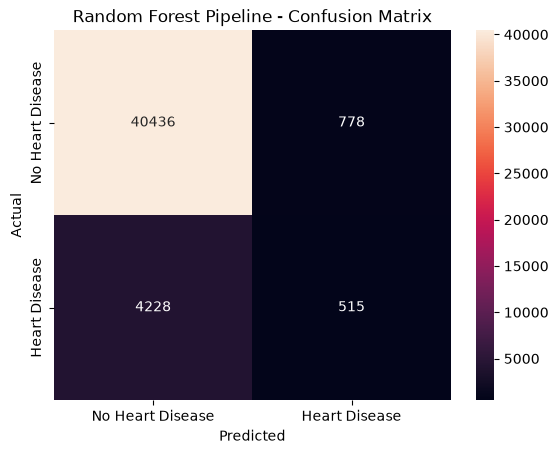

In [58]:
cm_rf_pipeline = confusion_matrix(y_test,y_pred_pipeline_rf)
sns.heatmap(cm_rf_pipeline,annot=True,fmt="d",xticklabels=["No Heart Disease", "Heart Disease"],yticklabels=["No Heart Disease", "Heart Disease"])
plt.title("Random Forest Pipeline - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Summary of Model Performance
The accuracy of the Random Forest Pipeline was 89%, which follows the same trend as logistic regression, where the model tends to have high bias toward the majority class ("No Heart Disease").
• No Heart Disease: High metrics (Precision: 0.91, Recall: 0.98, F1-Score: 0.94).
• Heart Disease: Low metrics (Precision: 0.40, Recall: 0.11, F1-Score: 0.17).
The model has high accuracy in general, but suffers greatly when detecting positive cases (low recall for heart disease), meaning that class imbalance handling is needed for both models.

In [59]:
pipeline_comparison = pd.DataFrame({"Model": ["Logistic Regression Pipeline","Random Forest Pipeline"],"Accuracy": [pipeline_lr_accuracy,pipeline_rf_accuracy],"Precision": [pipeline_lr_precision,pipeline_rf_precision],"Recall": [pipeline_lr_recall,pipeline_rf_recall],"F1-score": [pipeline_lr_f1,pipeline_rf_f1]})
pipeline_comparison

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression Pipeline,0.898470,0.536493,0.119334,0.195240
1,Random Forest Pipeline,0.891072,0.398299,0.108581,0.170643


## Visualization

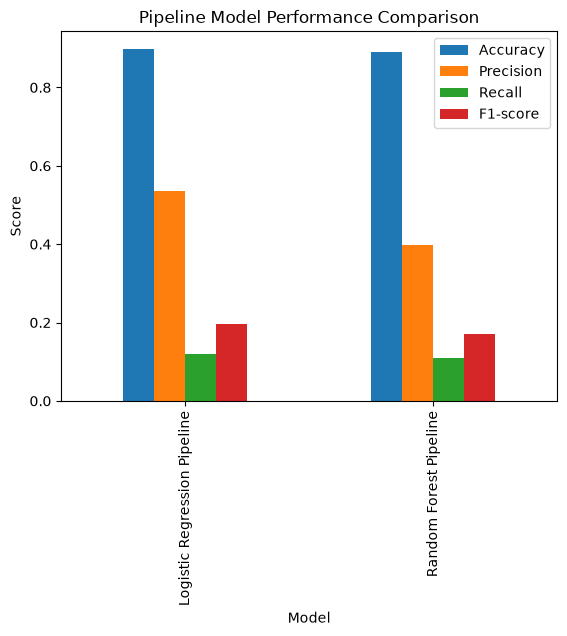

In [60]:
pipeline_plot = pipeline_comparison.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-score"]]
pipeline_plot.plot(kind="bar")
plt.title("Pipeline Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.show()

## Comparison Summary: Logistic Regression vs. Random Forest
The comparison table and Plot show that both models yield nearly identical results, with Logistic Regression slightly outperforming the Random Forest across most critical metrics.
- Performance: Both models are highly accurate but ineffective at detecting heart disease cases (very low Recall/F1-score).
- Preference: Logistic Regression is slightly better for this specific dataset, but neither model is currently reliable for clinical prediction due to the severe class imbalance.

## Comparing Models befor and after Pipeline
This comparison shows whether the additional engineered features improved the predictive performance.

In [61]:
m4_m5_comparison = pd.DataFrame({"Model": ["Logistic Regression","Logistic Regression Pipeline","Random Forest","Random Forest Pipeline"],"F1-score": [baseline_f1,pipeline_lr_f1,random_forest_f1,pipeline_rf_f1]})
m4_m5_comparison

,Model,F1-score
0,Logistic Regression,0.196308
1,Logistic Regression Pipeline,0.195240
2,Random Forest,0.171248
3,Random Forest Pipeline,0.170643


### Visualization

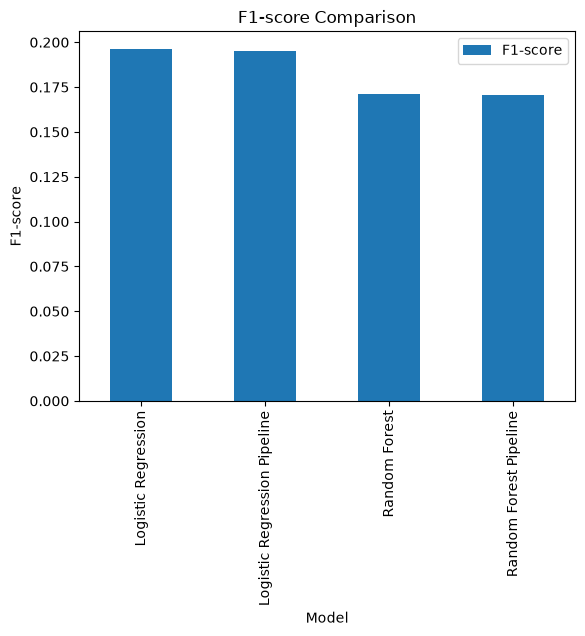

In [62]:
m4_m5_comparison.set_index("Model").plot(kind="bar")
plt.title("F1-score Comparison")
plt.xlabel("Model")
plt.ylabel("F1-score")
plt.show()

## F1-score Comparison Analysis
The plot presents the comparison of the F1-scores using four different model combinations (Base vs. Pipeline models for Logistic Regression and Random Forest).
Main Points:
- Advantage of Base Models: The models that do not use the pipeline configuration yield slightly better F1-scores than those based on it.
- Advantage of Logistic Regression: All the Logistic Regression models perform better than the models of Random Forest.
**General Conclusion: Feature engineering and pipeline had little effect on the F1-scores due to the dataset’s class imbalance.**

## Cross-Validation Using the Pipeline
Cross-validation can easily be applied to a Pipeline in Scikit-learn, which is one of its strengths.
The whole process of preprocessing is done within each fold,in the case of Logistic Regression, preprocessing is done within the pipeline before fitting the model.
This avoids leaking preprocessing information between training and validation folds.

In [63]:
cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

## Logistic Regression CV

In [64]:
pipeline_lr_cv_scores = cross_val_score(logistic_pipeline,x_train,y_train,cv=cv,scoring="f1",n_jobs=-1)
print("Logistic Regression Pipeline CV F1-scores:")
print(pipeline_lr_cv_scores)
print(f"Mean CV F1-score: "f"{pipeline_lr_cv_scores.mean()}")
print(f"Std CV F1-score: "f"{pipeline_lr_cv_scores.std()}")

Logistic Regression Pipeline CV F1-scores:
[0.19961282 0.21036782 0.19753611 0.19768439 0.21312178]
Mean CV F1-score: 0.2036645849412489
Std CV F1-score: 0.006694919332310093


## Random Forest CV

In [65]:
pipeline_rf_cv_scores = cross_val_score(random_forest_pipeline,x_train,y_train,cv=cv,scoring="f1",n_jobs=-1)
print("Random Forest Pipeline CV F1-scores:")
print(pipeline_rf_cv_scores)
print(f"Mean CV F1-score: "f"{pipeline_rf_cv_scores.mean()}")
print(f"Std CV F1-score: "f"{pipeline_rf_cv_scores.std()}")

Random Forest Pipeline CV F1-scores:
[0.17759162 0.17365523 0.17773153 0.16680708 0.17540915]
Mean CV F1-score: 0.17423892166482274
Std CV F1-score: 0.004009522718796194


## Final Pipeline Comparisons
The final pipeline comparisons involve performance of the test set and F1 score from cross validation.
Test set results indicate the performance of the models on unseen data whereas the cross validation mean and standard deviation reflect model stability.

In [66]:
final_comparison = pd.DataFrame({"Model": ["Logistic Regression Pipeline","Random Forest Pipeline"],"Test Accuracy": [pipeline_lr_accuracy,pipeline_rf_accuracy],"Test Precision": [pipeline_lr_precision,pipeline_rf_precision],"Test Recall": [pipeline_lr_recall,pipeline_rf_recall],"Test F1": [pipeline_lr_f1,pipeline_rf_f1],"Mean CV F1": [pipeline_lr_cv_scores.mean(),pipeline_rf_cv_scores.mean()],"Std CV F1": [pipeline_lr_cv_scores.std(),pipeline_rf_cv_scores.std()]})
final_comparison

,Model,Test Accuracy,Test Precision,Test Recall,Test F1,Mean CV F1,Std CV F1
0,Logistic Regression Pipeline,0.898470,0.536493,0.119334,0.195240,0.203665,0.006695
1,Random Forest Pipeline,0.891072,0.398299,0.108581,0.170643,0.174239,0.004010


## Best Pipeline Model
The model with the highest F1-score on the test set is chosen as the best pipeline model.

In [67]:
best_pipeline_model = final_comparison.loc[final_comparison["Test F1"].idxmax(),"Model"]
best_pipeline_f1 = final_comparison["Test F1"].max()
print("Best pipeline model:", best_pipeline_model)
print(f"Test F1-score: {best_pipeline_f1}")

Best pipeline model: Logistic Regression Pipeline
Test F1-score: 0.1952397378406347


### Conclusion: Final Selected Model
* The Best Performing Model: The selected best pipeline model is the **Logistic Regression Pipeline**, which has a Test F1-score of **0.195**.
* Performance in Cross-Validation: The average F1-score of the Logistic Regression Pipeline (0.204) in cross-validation is more consistent compared to Random Forest Pipeline (0.174).

# Final Results Summary( Overall Project Results)
The project utilized the Heart Disease Health Indicators dataset in order to develop supervised machine learning models that predict whether the patient has had any heart disease or heart attacks.
In the process of data preparation, the data set was checked for missing values, duplicates, data types, and valid values. There were no missing values detected, but 23,899 rows duplicated were deleted from the data set, which resulted in cleaning of the dataset with 229,781 rows and 22 features including target variable. The target variable `HeartDiseaseorAttack` is a binary classification target variable. The analysis revealed the class imbalance with much higher number of instances of the No Heart Disease class.
## M3 and M4 Model Results
First, Logistic Regression served as the baseline classifier, then as the second classifier – Random Forest was used.
The results of the original Logistic Regression model are:
* Accuracy: 0.9004
* Precision: 0.5537
* Recall: 0.1231
* F1-score: 0.2014
The results of the original Random Forest model are:
* Accuracy: 0.8948
* Precision: 0.4383
* Recall: 0.1107
* F1-score: 0.1768
Considering the F1-score for the test set, Logistic Regression is the model that performed better compared to the other original classifier.
M5 Feature Engineering and Pipeline Performance
Three extra features were engineered for M5:
- BMI_Category
- Age_Group
- Health_Burden
Scikit-learn Pipeline was applied to create a consistent workflow for the machine learning task including feature engineering, preprocessing and modeling steps.
### The performance metrics for the Logistic Regression Pipeline are as follows:
- Accuracy: 0.8985
- Precision: 0.5365
- Recall: 0.1193
- F1-score: 0.1952
- Mean 5-Fold CV F1-score: 0.2037
- CV Standard Deviation: 0.0067
### The performance metrics for the Random Forest Pipeline are as follows:
- Accuracy: 0.8911
- Precision: 0.3983
- Recall: 0.1086
- F1-score: 0.1706
- Mean 5-Fold CV F1-score: 0.1742
- CV Standard Deviation: 0.0040
### Conclusion of Final Model Comparison
Logistic Regression is still the best-performing pipeline considering the test-set F1-score.
It can be seen from the comparison of the original models and the pipeline models that the engineered features do not help significantly improve the test-set F1-score. Nevertheless, the Pipeline creates an important contribution to the structure and the consistency of the machine learning
### Final Conclusion
From the findings, it can be concluded that accuracy cannot be used as a good performance measure in this case study due to the presence of class imbalance in the dataset.
Both models performed well with very high accuracy but poor recall and F1-score in the Heart Disease class. This shows that the two models cannot easily predict positive heart disease classes.
The Logistic Regression Pipeline model was chosen as the best pipeline model with a very high test-set F1-score of 0.1952. But its poor recall means more improvement needs to be done before the model can be considered a useful tool in detecting heart disease cases.
All in all, models M1 to M5 formed a comprehensive supervised learning process starting from data importation and exploration to comparison, feature generation, and Scikit-learn Pipeline.

# Unsupervised Learning

In this section, unsupervised learning techniques are applied to discover hidden patterns in the patient data.

The target variable HeartDiseaseorAttack is excluded from all unsupervised model fitting.

Unlike supervised learning, the objective is not to predict a known target. Instead, the objective is to identify natural patient groups, reduce dimensionality, visualize hidden structures, and detect unusual observations.

### Prepare Data for Unsupervised Learning

In [3]:
x_unsupervised = df.drop(columns=['HeartDiseaseorAttack'])
print("Features used for unsupervised learning:")
print(x_unsupervised.shape)
x_unsupervised.head()

Features used for unsupervised learning:
(253680, 21)


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysActivity,Fruits,Veggies,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


## Scaling

In [4]:
scaler_unsupervised = StandardScaler()
x_scaled = scaler_unsupervised.fit_transform(x_unsupervised)
print(x_scaled.shape)

(253680, 21)


## Feature Scaling

StandardScaler is applied before clustering because distance-based algorithms such as K-Means and DBSCAN are sensitive to feature scale.
Scaling ensures that features with larger numerical ranges do not dominate the distance calculations.

## K-Means
K-Means clustering was applied to group patients into different clusters based on similarities in their health and lifestyle characteristics. The number of clusters was evaluated using the Silhouette Score to select a suitable clustering structure.

In [5]:
inertias = []
for k in range(1, 11):
    km = KMeans(n_clusters=k,random_state=42,n_init=10)
    km.fit(x_scaled)
    inertias.append(km.inertia_)

### Elbow Method

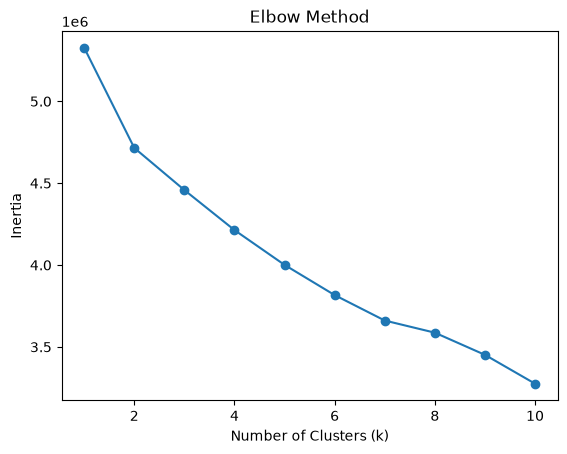

In [6]:
plt.plot(range(1, 11), inertias, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

### Elbow Method Analysis

- **Goal:** Determine the optimal number of clusters ($k$) for the dataset.
- **Selected $k$:** **4**
- **Justification:** Based on the plot, the curve bends (forms the "elbow") at $k = 4$, where the rate of decrease in inertia significantly slows down, representing the best balance between model simplicity and cluster cohesion.
- **Alternative Choice ($k = 3$):** This is also a strong candidate as the curve begins to flatten and descend at a highly steady.

In [9]:
sample_size = 10000
rng = np.random.RandomState(42)
sample_indices = rng.choice(x_scaled.shape[0],size=sample_size,replace=False)
x_sample = x_scaled[sample_indices]

The Silhouette Score calculated on a random sample of 10,000 observations to reduce computation time.

## Silhouette Score

In [11]:
silhouette_scores = {}

for k in [3, 4]:
    km = KMeans(n_clusters=k,random_state=42,n_init=10)
    labels = km.fit_predict(x_sample)
    score = silhouette_score(x_sample,labels)

    silhouette_scores[k] = score

silhouette_scores

{3: 0.08546751959640407, 4: 0.09548661598189508}

In [12]:
for k, score in silhouette_scores.items():
    print(f"k={k}: Silhouette Score = {score}")

k=3: Silhouette Score = 0.08546751959640407
k=4: Silhouette Score = 0.09548661598189508


In [15]:
best_k = 4  
kmeans = KMeans(n_clusters=best_k,random_state=42,n_init=10)
kmeans_labels = kmeans.fit_predict(x_scaled)

### Silhouette Score

The Silhouette Score was used to compare the candidate cluster numbers.

A higher score indicates that the observations are better separated from neighboring clusters.

**The final value of k  selected was 4** based on the combination of the Elbow Method and Silhouette Score.

### Add K-Means Cluster

In [16]:
df['KMeans_Cluster'] = kmeans_labels
df['KMeans_Cluster'].value_counts()

KMeans_Cluster
0    113279
3     87923
1     40209
2     12269
Name: count, dtype: int64

Assigned each observation to one of the 4 clusters based on the K-Means clustering model. The distribution of data points across the clusters is displayed above.

### Cluster Profiles

In [ ]:
cluster_profile = df.groupby('KMeans_Cluster').mean(numeric_only=True)
cluster_profile

,HeartDiseaseorAttack,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
KMeans_Cluster,,,,,,,,,,,,,,,,,,,,,
0,0.015899,0.077358,0.194431,0.944597,26.543490,0.314824,0.005411,0.032936,0.879298,0.694657,...,1.000000,0.052967,1.939645,2.040184,1.357983,0.020807,0.405318,6.565242,5.411780,6.917275
1,0.245119,0.680892,0.600512,0.982815,31.479594,0.604417,0.148872,0.740083,0.451217,0.546296,...,0.996294,0.187520,3.896168,9.803427,17.751100,0.781666,0.349076,9.121465,4.478848,4.176130
2,0.065857,0.337843,0.326106,0.862662,28.843100,0.493031,0.027631,0.234819,0.694352,0.568995,...,0.000082,0.368490,2.679925,4.719130,4.266607,0.146385,0.484392,6.143288,4.522373,4.631510
3,0.129977,0.779580,0.653060,0.990696,29.270828,0.527825,0.038147,0.443035,0.746699,0.605769,...,1.000000,0.037453,2.591222,1.418491,1.776543,0.080661,0.521058,9.687420,4.919964,5.998692


Calculated the mean values of all features for each cluster to analyze and interpret the characteristics of the identified groups.

In [18]:
df.groupby('KMeans_Cluster')['HeartDiseaseorAttack'].mean()

KMeans_Cluster
0    0.015899
1    0.245119
2    0.065857
3    0.129977
Name: HeartDiseaseorAttack, dtype: float64

Examined the average rate of heart disease or attack across each cluster to evaluate the risk distribution among the groups.

## DBSCAN
DBSCAN was used to identify groups of patients based on the density of their observations. Unlike K-Means, it can detect noise points and does not require specifying the number of clusters in advance.

In [19]:
dbscan = DBSCAN(eps=0.5,min_samples=5)
dbscan_labels = dbscan.fit_predict(x_scaled)
df['DBSCAN_Cluster'] = dbscan_labels

In [20]:
unique_labels = set(dbscan_labels)
n_clusters = len(unique_labels - {-1})
n_noise = np.sum(dbscan_labels == -1)
print("Clusters:", n_clusters)
print("Noise points:", n_noise)

Clusters: 1390
Noise points: 171927


#### Evaluate DBSCAN Results

Calculated the number of distinct clusters formed and the count of noise points (labeled as -1) identified by the DBSCAN model.

## Hierarchical Clustering
Hierarchical clustering was used to explore the relationships between patients by building a hierarchy of clusters. A dendrogram was used to visualize how observations were grouped at different levels of similarity.

### Sample Selection for Hierarchical Clustering
Selected a subset of the scaled data to optimize computation time and memory usage for the hierarchical clustering algorithm.

In [21]:
sample_size = 3000
x_hierarchical = x_scaled[:sample_size]

### Linkage Matrix Calculation

Computed the hierarchical clustering linkage matrix using Ward's method to minimize the total within-cluster variance.

In [22]:
Z = linkage(x_hierarchical,method='ward')

### Hierarchical Clustering Dendrogram


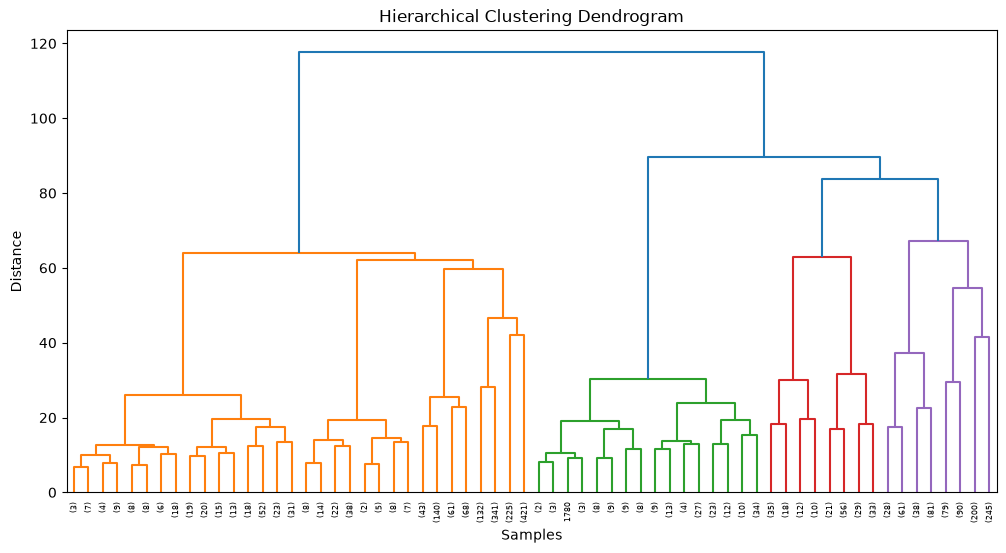

In [ ]:
plt.figure(figsize=(12,6))
dendrogram(Z,truncate_mode='level',p=5)
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.title("Hierarchical Clustering Dendrogram")

plt.show()

### Plot Analysis

- **Cluster Merges:** The dendrogram visualizes how individual samples and smaller clusters are progressively merged into larger groups based on distance.
- **Height/Distance Threshold:** The vertical axis (Distance) shows the dissimilarity between merged clusters, where taller branches indicate more distinct groupings.

## PCA
Principal Component Analysis (PCA) was applied to reduce the dimensionality of the dataset while preserving as much variance as possible. This helped simplify the feature space and make the data easier to analyze and visualize.
A full PCA model was first fitted on the scaled dataset to calculate the explained variance of each principal component and the cumulative explained variance. This was used to determine how many components were needed to retain most of the information in the dataset.

In [26]:
pca_full = PCA()
X_pca_full = pca_full.fit_transform(x_scaled)
explained_variance = (pca_full.explained_variance_ratio_)
cumulative_variance = (explained_variance.cumsum())

### Cumulative Explained Variance Plot

Plotted the cumulative explained variance against the number of components, using a dashed threshold line at **95% (0.95)** to determine the optimal dimensionality reduction.

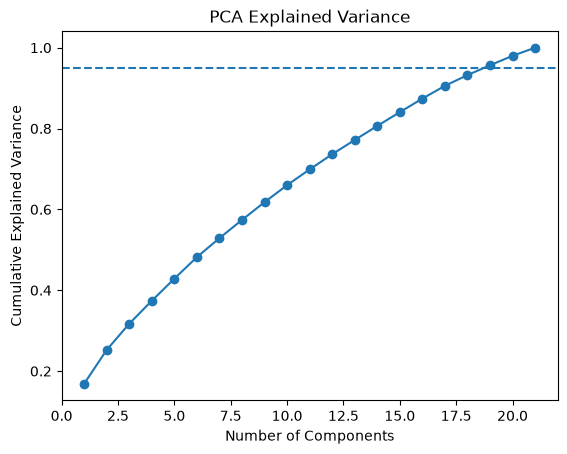

In [27]:

plt.plot(range(1,len(cumulative_variance)+1),cumulative_variance,marker='o')
plt.axhline(y=0.95,linestyle='--')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.show()

### Variance Analysis 

- **Growth Trend:** The cumulative variance curve rises steeply with the first few components and then gradually flattens out.
- **Component Selection:** The dashed line indicates that **19 components** are required to capture at least 95% of the total dataset variance while reducing dimensionality from 21 to 19 features.

### PCA — 95%

In [28]:
n_components_95 = (cumulative_variance >= 0.95).argmax() + 1

print("Components needed for 95% variance:",n_components_95)

Components needed for 95% variance: 19


In [31]:
pca_95 = PCA(n_components=n_components_95)
X_pca_95 = pca_95.fit_transform(x_scaled)
print("Original dimensions:",x_scaled.shape[1])
print("Reduced dimensions:",X_pca_95.shape[1])
print("Variance retained:",pca_95.explained_variance_ratio_.sum())

Original dimensions: 21
Reduced dimensions: 19
Variance retained: 0.9565195575587719


### PCA 2D Dimensionality Reduction
Transformed the high-dimensional scaled dataset into **2 principal components** to enable 2D visualization of the data distribution.

In [32]:
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(x_scaled)

### K-Means Clusters Projection on 2D PCA

Visualized the 4 K-Means clusters by projecting the data points onto the first two principal components (PC1 and PC2) in a scatter plot.

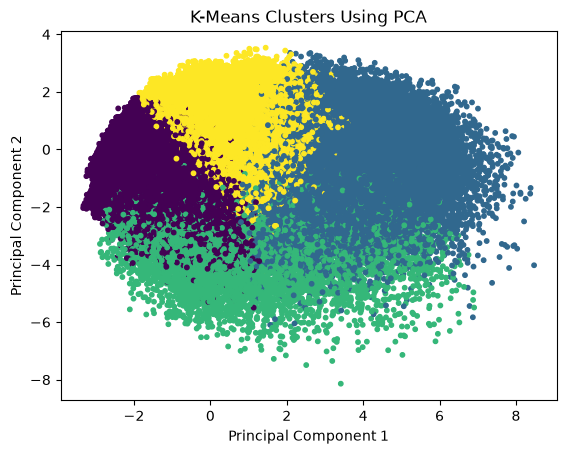

In [33]:
plt.scatter(X_pca_2d[:,0],X_pca_2d[:,1],c=kmeans_labels,s=10)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters Using PCA")
plt.show()

### Cluster Visualization Observations

* **Separation and Structure:** The scatter plot shows the spatial distribution of the 4 clusters across the principal component axes.
* **Cluster Boundaries:** Distinct groupings (represented by different colors: purple, yellow, teal/blue, and green) occupy separate regions of the 2D projection space, demonstrating how K-Means partitioned the data structurally.

## t-SNE
t-SNE was used to project the high-dimensional patient data into two dimensions for visualization. It helps reveal local patterns and similarities between observations that may not be easily visible in the original feature space.

### Sample Selection for t-SNE
Extracted a subset of 5,000 samples from the scaled dataset along with their corresponding K-Means labels to optimize the computational performance of t-SNE.

In [35]:
sample_size = 5000
X_tsne_sample = x_scaled[:sample_size]
labels_tsne = kmeans_labels[:sample_size]

### t-SNE Dimensionality Reduction
Initialized and fitted the t-SNE model (`n_components=2`, `perplexity=30`) to map the high-dimensional features into a 2D space while preserving local neighborhood structures.

In [ ]:
tsne = TSNE(n_components=2,perplexity=30,random_state=42)
X_tsne = tsne.fit_transform(X_tsne_sample)

### t-SNE 2D Scatter Plot
Plotted the 2D embedding generated by t-SNE, coloring the points according to their respective K-Means cluster assignments to visualize non-linear separability.

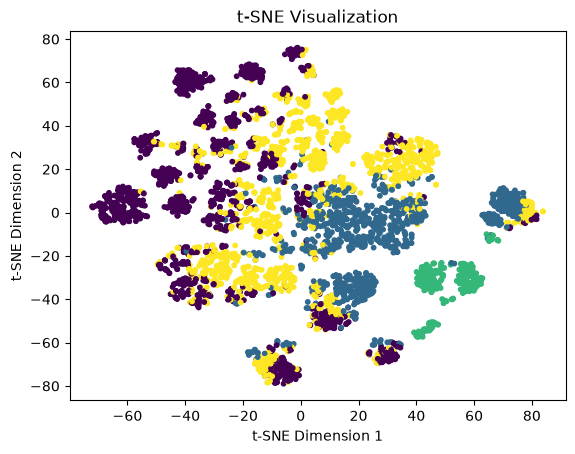

In [37]:
plt.scatter(X_tsne[:,0],X_tsne[:,1],c=labels_tsne,s=10)
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.title("t-SNE Visualization")
plt.show()

### t-SNE Plot Analysis
* **Non-Linear Clusters:** The t-SNE projection reveals multiple distinct, highly localized islands and clusters rather than a single continuous mass.
* **Cluster Separation:** Colors corresponding to the K-Means clusters form separated, island-like groupings in the 2D manifold space, highlighting how t-SNE captures complex local structures and non-linear patterns within the data.

### PCA vs t-SNE
PCA and t-SNE were used for different visualization purposes.
PCA preserves global variance and can also be used as a dimensionality reduction technique.
t-SNE focuses on local neighborhoods and is mainly used for visualization.
PCA is faster and provides components based on combinations of the original features, while t-SNE dimensions do not have a direct physical interpretation.
Therefore, PCA is more appropriate for dimensionality reduction, while t-SNE is useful for exploring local structures visually.

## Isolation Forest

### Isolation Forest Model Initialization

Initialized and fitted the **Isolation Forest** algorithm with a contamination rate of **0.05 (5%)** to isolate and detect multivariate anomalies within the scaled dataset.

In [38]:
iso = IsolationForest(contamination=0.05,random_state=42)
anomaly_labels = iso.fit_predict(x_scaled)
df['Anomaly'] = anomaly_labels

In [39]:
df['Anomaly'].value_counts()

Anomaly
 1    240996
-1     12684
Name: count, dtype: int64

### Anomaly Summary and Percentage

Calculated the exact count and percentage of detected anomalies to verify that the model correctly flagged 5% of the total dataset records.

In [40]:
n_anomalies = (df['Anomaly'] == -1).sum()
print("Number of anomalies:",n_anomalies)
print("Percentage:",n_anomalies / len(df) * 100)

Number of anomalies: 12684
Percentage: 5.0


### Anomaly Detection Results

* **Total Anomalies:** The model identified **12,684** anomalous records out of the total dataset.
* **Proportion:** This represents exactly **5.0%** of the data, matching the predefined contamination parameter.

### Inspect Anomalies

In [41]:
anomalies = df[df['Anomaly'] == -1]
anomalies.head(2)

,HeartDiseaseorAttack,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysActivity,Fruits,...,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,KMeans_Cluster,DBSCAN_Cluster,Anomaly
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,7.0,6.0,1.0,2,-1,-1
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,30.0,30.0,1.0,0.0,9.0,4.0,8.0,1,-1,-1


## Anomaly Analysis
Isolation Forest identified observations that are relatively unusual compared with the majority of the dataset.
An anomaly does not necessarily represent an incorrect record or a patient with heart disease. It simply indicates that the observation has an unusual combination of characteristics compared with the learned normal patterns.

In [42]:
df.groupby('KMeans_Cluster')['HeartDiseaseorAttack'].mean()

KMeans_Cluster
0    0.015899
1    0.245119
2    0.065857
3    0.129977
Name: HeartDiseaseorAttack, dtype: float64

### Anomaly Heart Disease Rate Comparison

Calculated and compared the average rate of heart disease or attack between normal instances (1) and detected anomalies (-1) to see if unusual patterns correlate with higher health risks.

In [43]:
df.groupby('Anomaly')['HeartDiseaseorAttack'].mean()

Anomaly
-1    0.279486
 1    0.084433
Name: HeartDiseaseorAttack, dtype: float64

### Anomaly Analysis Observations

* **Elevated Risk in Anomalies:** The mean heart disease rate for anomalies ($-1$) is significantly higher (**27.9%**) compared to normal data points ($1$) which sit at **8.4%**.
* **Risk Correlation:** This indicates that the records flagged as statistical anomalies by the Isolation Forest frequently correspond to individuals experiencing higher health vulnerabilities or more severe risk indicators.

### Normalized Distribution Crosstab

Generated a normalized cross-tabulation table to analyze the proportional breakdown of heart disease outcomes within normal records versus anomalous records.

In [44]:
pd.crosstab(df['Anomaly'],df['HeartDiseaseorAttack'],normalize='index')

HeartDiseaseorAttack,0.0,1.0
Anomaly,,
-1,0.720514,0.279486
1,0.915567,0.084433


## Post-hoc Analysis
After completing the unsupervised learning process, the original heart disease target was used only for interpretation.
This analysis investigates whether the naturally discovered patient groups or detected anomalies show different heart disease rates.
The target variable was not used during clustering, dimensionality reduction, or anomaly detection.

## Unsupervised Learning Summary

Unsupervised learning was used to discover hidden patterns and patient structures without using the heart disease target.

| Technique | Purpose |
|---|---|
| K-Means | Discover patient groups |
| DBSCAN | Discover dense groups and noise |
| Hierarchical Clustering | Explore hierarchical relationships |
| PCA | Reduce dimensions and preserve variance |
| t-SNE | Visualize local structure |
| Isolation Forest | Detect unusual observations |

These techniques complement supervised learning by focusing on patient similarity, hidden structures, and unusual observations rather than directly predicting heart disease.